## Homework 3: Supervised Learning

### Exercise 4: Logistic Regression on a Real Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    z = np.clip(z, -50, 50)
    return 1.0 / (1.0 + np.exp(-z))

def add_bias_column(X):
    # X: (N, d) -> (N, d+1) with leading 1s
    return np.hstack([np.ones((X.shape[0], 1)), X])

def standardize_fit(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma = np.where(sigma < 1e-12, 1.0, sigma)
    return mu, sigma

def standardize_apply(X, mu, sigma):
    return (X - mu) / sigma

def train_test_split(X, y, test_ratio=0.2, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(X))
    rng.shuffle(idx)
    n_test = int(len(X) * test_ratio)
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

def ensure_1d(y):
    return y.reshape(-1)

def L(theta, X, y):
    theta = theta.reshape(-1)
    y = ensure_1d(y)
    p = sigmoid(X @ theta)
    eps = 1e-12
    p = np.clip(p, eps, 1 - eps)
    return float(-(y * np.log(p) + (1 - y) * np.log(1 - p)).mean())

def grad_L(theta, X, y):
    theta = theta.reshape(-1)
    y = ensure_1d(y)
    p = sigmoid(X @ theta)
    g = (X.T @ (p - y)) / len(y)
    return g

def predict_proba(theta, X):
    theta = theta.reshape(-1)
    return sigmoid(X @ theta)

def predict_label(theta, X, threshold=0.5):
    return (predict_proba(theta, X) >= threshold).astype(int)

def accuracy(theta, X, y, threshold=0.5):
    y = ensure_1d(y).astype(int)
    yhat = predict_label(theta, X, threshold=threshold)
    return float((yhat == y).mean())

In [4]:
def gradient_descent(L_fn, grad_L_fn, X, y, theta0, eta0, maxit, tolL=1e-6, toltheta=1e-9):
    theta = theta0.astype(float).copy().reshape(-1)
    thetas = [theta.copy()]
    losses = [L_fn(theta, X, y)]
    grad_norms = [np.linalg.norm(grad_L_fn(theta, X, y))]

    for it in range(maxit):
        g = grad_L_fn(theta, X, y)
        if np.linalg.norm(g) < tolL:
            break

        theta_next = theta - eta0 * g

        if np.linalg.norm(theta_next - theta) < toltheta:
            theta = theta_next
            thetas.append(theta.copy())
            losses.append(L_fn(theta, X, y))
            grad_norms.append(np.linalg.norm(grad_L_fn(theta, X, y)))
            break

        theta = theta_next
        thetas.append(theta.copy())
        losses.append(L_fn(theta, X, y))
        grad_norms.append(np.linalg.norm(grad_L_fn(theta, X, y)))

    return theta, it, np.array(thetas), np.array(losses), np.array(grad_norms)

def stochastic_gradient_descent(L_fn, grad_L_fn, X, y, theta0, eta=1e-3, epochs=200, batch_size=32, seed=0):
    rng = np.random.default_rng(seed)
    theta = theta0.astype(float).copy().reshape(-1)

    N = X.shape[0]
    thetas = [theta.copy()]
    losses = []
    accs = []
    grad_norms = []

    for _ in range(epochs):
        idx = rng.permutation(N)
        Xs = X[idx]
        ys = y[idx]

        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            Xb = Xs[start:end]
            yb = ys[start:end]
            g = grad_L_fn(theta, Xb, yb)
            theta = theta - eta * g
            thetas.append(theta.copy())

        losses.append(L_fn(theta, X, y))
        accs.append(accuracy(theta, X, y, threshold=0.5))
        grad_norms.append(np.linalg.norm(grad_L_fn(theta, X, y)))

    return theta, np.array(thetas), np.array(losses), np.array(accs), np.array(grad_norms)

def adam(L_fn, grad_L_fn, X, y, theta0, eta=1e-3, epochs=200, batch_size=32, beta1=0.9, beta2=0.999, eps=1e-8, seed=0):
    rng = np.random.default_rng(seed)
    theta = theta0.astype(float).copy().reshape(-1)

    m = np.zeros_like(theta)
    v = np.zeros_like(theta)
    t = 0

    N = X.shape[0]
    thetas = [theta.copy()]
    losses = []
    accs = []
    grad_norms = []

    for _ in range(epochs):
        idx = rng.permutation(N)
        Xs = X[idx]
        ys = y[idx]

        for start in range(0, N, batch_size):
            end = min(start + batch_size, N)
            Xb = Xs[start:end]
            yb = ys[start:end]

            g = grad_L_fn(theta, Xb, yb)

            t += 1
            m = beta1 * m + (1 - beta1) * g
            v = beta2 * v + (1 - beta2) * (g * g)

            m_hat = m / (1 - beta1 ** t)
            v_hat = v / (1 - beta2 ** t)

            theta = theta - eta * (m_hat / (np.sqrt(v_hat) + eps))
            thetas.append(theta.copy())

        losses.append(L_fn(theta, X, y))
        accs.append(accuracy(theta, X, y, threshold=0.5))
        grad_norms.append(np.linalg.norm(grad_L_fn(theta, X, y)))

    return theta, np.array(thetas), np.array(losses), np.array(accs), np.array(grad_norms)

In [5]:
def plot_training_curves(losses, accs=None, title_prefix=""):
    fig, axs = plt.subplots(1, 2 if accs is not None else 1, figsize=(14, 5))
    if accs is None:
        ax = axs
        ax.plot(losses)
        ax.set_title(f"{title_prefix} Loss vs Epoch")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("BCE Loss")
        ax.grid(alpha=0.2)
    else:
        ax0, ax1 = axs
        ax0.plot(losses)
        ax0.set_title(f"{title_prefix} Loss vs Epoch")
        ax0.set_xlabel("Epoch")
        ax0.set_ylabel("BCE Loss")
        ax0.grid(alpha=0.2)

        ax1.plot(accs)
        ax1.set_title(f"{title_prefix} Accuracy vs Epoch")
        ax1.set_xlabel("Epoch")
        ax1.set_ylabel("Accuracy")
        ax1.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()
    
def plot_dataset_and_boundary(theta, X_design, y, title="Decision Boundary"):
    theta = theta.reshape(-1)
    y = ensure_1d(y).astype(int)

    # Extract raw features: columns after bias
    X_raw = X_design[:, 1:3]  # (N,2)
    x1 = X_raw[:, 0]
    x2 = X_raw[:, 1]

    plt.figure(figsize=(7, 6))
    plt.scatter(x1[y == 0], x2[y == 0], label="Class 0", alpha=0.8)
    plt.scatter(x1[y == 1], x2[y == 1], label="Class 1", alpha=0.8)

    # decision boundary: theta0 + theta1*x1 + theta2*x2 = 0
    t0, t1, t2 = float(theta[0]), float(theta[1]), float(theta[2])

    x1_min, x1_max = x1.min() - 1, x1.max() + 1
    xs = np.linspace(x1_min, x1_max, 200)

    if abs(t2) > 1e-12:
        ys = -(t0 + t1 * xs) / t2
        plt.plot(xs, ys, linewidth=2, label="theta^T x = 0")
    else:
        if abs(t1) > 1e-12:
            xv = -t0 / t1
            plt.axvline(xv, linewidth=2, label="theta^T x = 0")

    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.legend()
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.show()

In [6]:
def confusion_matrix_binary(y_true, y_pred):
    y_true = ensure_1d(y_true).astype(int)
    y_pred = ensure_1d(y_pred).astype(int)
    TP = int(np.sum((y_true == 1) & (y_pred == 1)))
    TN = int(np.sum((y_true == 0) & (y_pred == 0)))
    FP = int(np.sum((y_true == 0) & (y_pred == 1)))
    FN = int(np.sum((y_true == 1) & (y_pred == 0)))
    return TP, FP, FN, TN

def precision_recall_f1(y_true, y_pred):
    TP, FP, FN, TN = confusion_matrix_binary(y_true, y_pred)
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    acc = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0.0
    return {
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

def print_metrics_table(theta, X, y, thresholds=(0.5, 0.3, 0.7), title="Metrics"):
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)
    for thr in thresholds:
        y_pred = predict_label(theta, X, threshold=thr)
        m = precision_recall_f1(y, y_pred)
        print(f"\nThreshold = {thr}")
        print(f"Confusion (TP, FP, FN, TN) = ({m['TP']}, {m['FP']}, {m['FN']}, {m['TN']})")
        print(f"Accuracy  = {m['accuracy']:.4f}")
        print(f"Precision = {m['precision']:.4f}")
        print(f"Recall    = {m['recall']:.4f}")
        print(f"F1-score  = {m['f1']:.4f}")

In [7]:
def make_toy_2d_dataset(n0=200, n1=200, mu0=(-2, -2), mu1=(2, 2), var0=1.0, var1=0.5, seed=0):
    rng = np.random.default_rng(seed)
    cov0 = var0 * np.eye(2)
    cov1 = var1 * np.eye(2)

    X0 = rng.multivariate_normal(mean=np.array(mu0), cov=cov0, size=n0)
    X1 = rng.multivariate_normal(mean=np.array(mu1), cov=cov1, size=n1)

    y0 = np.zeros(n0, dtype=int)
    y1 = np.ones(n1, dtype=int)

    X = np.vstack([X0, X1])
    y = np.concatenate([y0, y1])

    return X, y

def run_toy_exercises():
    X_raw, y = make_toy_2d_dataset(seed=0)
    X = add_bias_column(X_raw)  # design matrix (N,3)

    theta0 = np.zeros(X.shape[1], dtype=float)
    eta = 1e-1
    maxit = 2000
    tolL = 1e-6
    toltheta = 1e-9

    theta_gd, _, _, losses_gd, _ = gradient_descent(
        L, grad_L, X, y, theta0, eta0=eta, maxit=maxit, tolL=tolL, toltheta=toltheta
    )

    print("theta =", theta_gd)
    print("final loss =", losses_gd[-1])
    print("final acc  =", accuracy(theta_gd, X, y))
    plot_training_curves(losses_gd, accs=None, title_prefix="Full GD (Toy 2D)")
    plot_dataset_and_boundary(theta_gd, X, y, title="Toy 2D Logistic Regression (GD Decision Boundary)")

    batch_sizes = [1, 10, len(X)]
    epochs = 200
    eta_sgd = 1e-2

    results = {}
    for bs in batch_sizes:
        theta_sgd, _, losses, accs, _ = stochastic_gradient_descent(
            L, grad_L, X, y, theta0=np.zeros(X.shape[1]), eta=eta_sgd, epochs=epochs, batch_size=bs, seed=0
        )
        results[bs] = (theta_sgd, losses, accs)

        print(f"\nBatch size = {bs}")
        print("theta =", theta_sgd)
        print("final loss =", losses[-1])
        print("final acc  =", accs[-1])
        plot_training_curves(losses, accs, title_prefix=f"SGD (Toy 2D) - batch={bs}")
        plot_dataset_and_boundary(theta_sgd, X, y, title=f"Toy 2D Logistic Regression (SGD, batch={bs})")

    print_metrics_table(theta_gd, X, y, thresholds=(0.5, 0.3, 0.7), title="[Exercise 3] Metrics (Toy 2D) using GD model")

In [ ]:
def load_diabetes_csv(path):
    df = pd.read_csv(path)
    y = df["Outcome"].values.astype(int)
    X = df.drop(columns=["Outcome"]).values.astype(float)
    return X, y, df

def preprocess_diabetes(X, y):
    mu, sigma = standardize_fit(X)
    Xs = standardize_apply(X, mu, sigma)
    X_design = add_bias_column(Xs)
    return X_design, y, (mu, sigma)

def run_diabetes_ex(diabetes_csv_path="diabetes.csv"):
    X_raw, y, _ = load_diabetes_csv(diabetes_csv_path)
    X, y, (_, _) = preprocess_diabetes(X_raw, y)

    Xtr, Xte, ytr, yte = train_test_split(X, y, test_ratio=0.2, seed=0)

    # Train with SGD (batch=32, lr=1e-3, 200 epochs)
    theta0 = np.zeros(Xtr.shape[1], dtype=float)

    lr = 1e-3
    epochs = 200
    batch_size = 32

    theta_sgd, _, losses_sgd, accs_sgd, _ = stochastic_gradient_descent(
        L, grad_L, Xtr, ytr, theta0, eta=lr, epochs=epochs, batch_size=batch_size, seed=0
    )

    # Train with Adam (same lr, batch, epochs)
    theta_adam, _, losses_adam, accs_adam, _ = adam(
        L, grad_L, Xtr, ytr, theta0, eta=lr, epochs=epochs, batch_size=batch_size, seed=0
    )

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))
    axs[0].plot(losses_sgd, label="SGD")
    axs[0].plot(losses_adam, label="Adam")
    axs[0].set_title("Diabetes: Loss vs Epoch")
    axs[0].set_xlabel("Epoch")
    axs[0].set_ylabel("BCE Loss")
    axs[0].grid(alpha=0.2)
    axs[0].legend()

    axs[1].plot(accs_sgd, label="SGD")
    axs[1].plot(accs_adam, label="Adam")
    axs[1].set_title("Diabetes: Accuracy vs Epoch (train)")
    axs[1].set_xlabel("Epoch")
    axs[1].set_ylabel("Accuracy")
    axs[1].grid(alpha=0.2)
    axs[1].legend()

    plt.tight_layout()
    plt.show()

    print("\n Diabetes dataset evaluation (test set)")
    for name, theta in [("SGD", theta_sgd), ("Adam", theta_adam)]:
        acc_te = accuracy(theta, Xte, yte, threshold=0.5)
        print(f"\n{name} final test accuracy (thr=0.5) = {acc_te:.4f}")
        print_metrics_table(theta, Xte, yte, thresholds=(0.5, 0.3, 0.7),
                            title=f"Diabetes (TEST) metrics for {name}")

    print("\nFinal learned parameters:")
    print("theta_sgd  =", theta_sgd)
    print("theta_adam =", theta_adam)

theta = [-0.39153761  2.1620034   2.3185066 ]
final loss = 0.003510490840485587
final acc  = 1.0


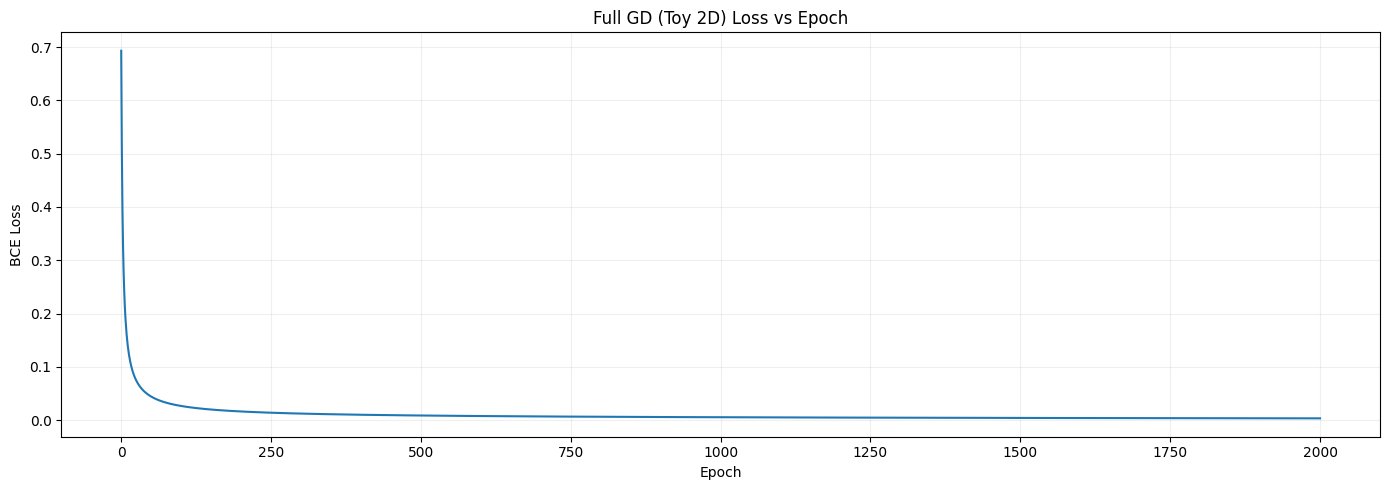

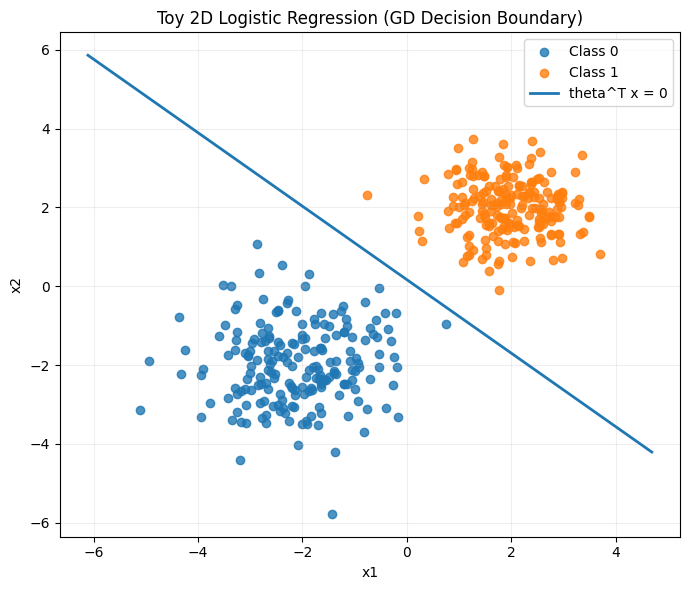


Batch size = 1
theta = [-0.80355249  2.69241294  3.17793197]
final loss = 0.0013048752136276412
final acc  = 1.0


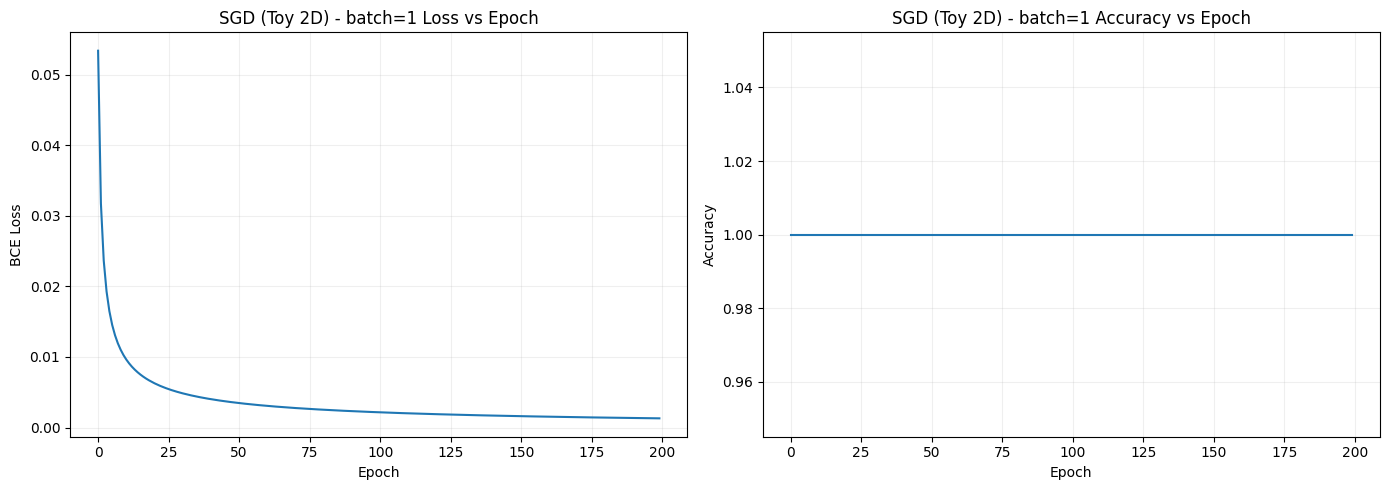

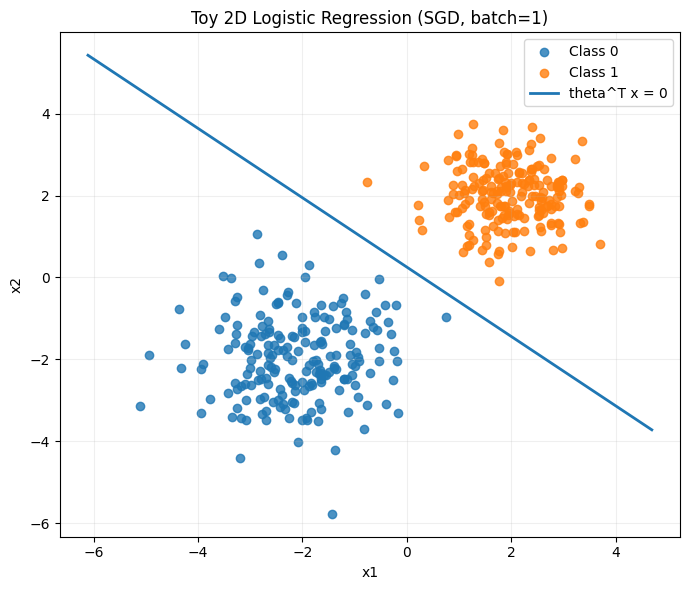


Batch size = 10
theta = [-0.21631288  1.82959779  1.8733171 ]
final loss = 0.00647075242296432
final acc  = 1.0


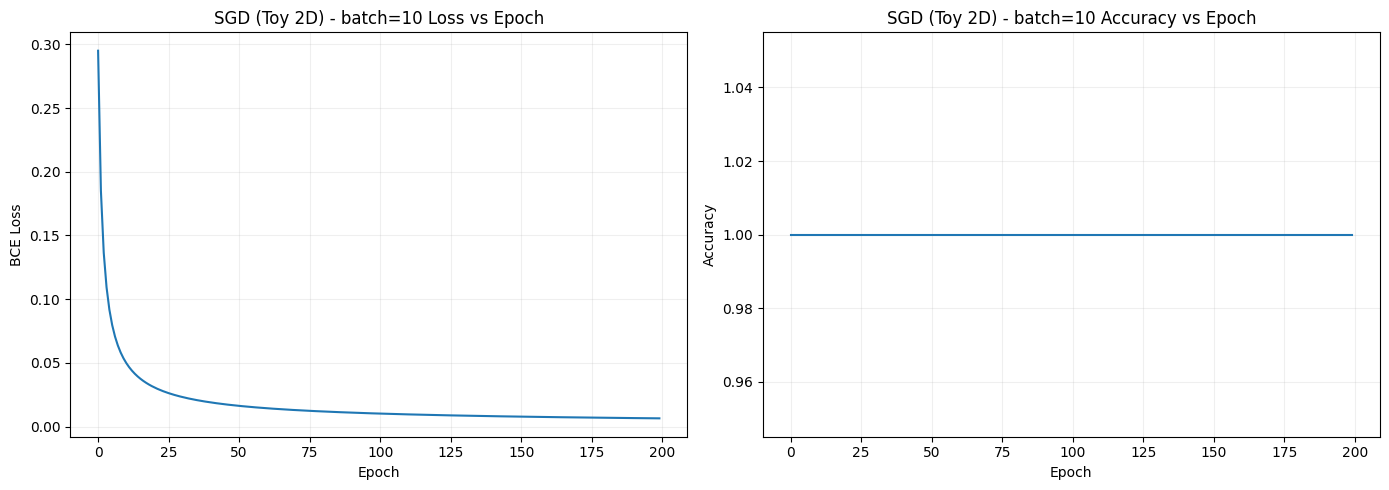

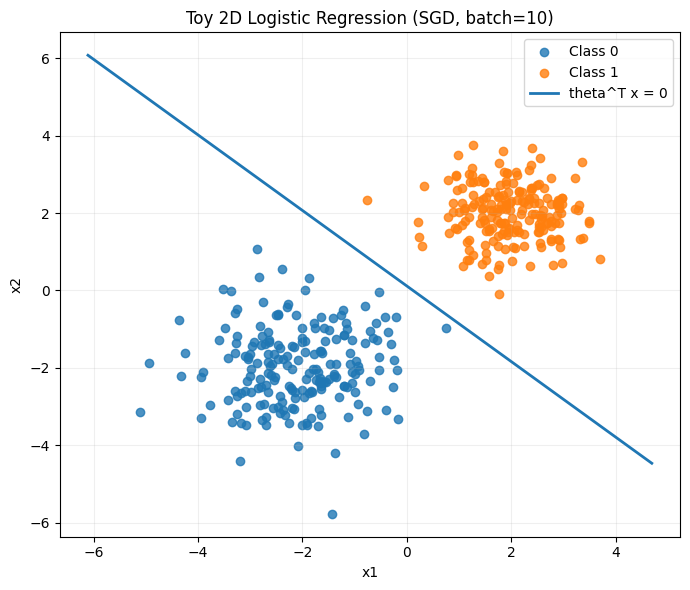


Batch size = 400
theta = [-0.0032534   0.6617455   0.64795378]
final loss = 0.09179491027505443
final acc  = 1.0


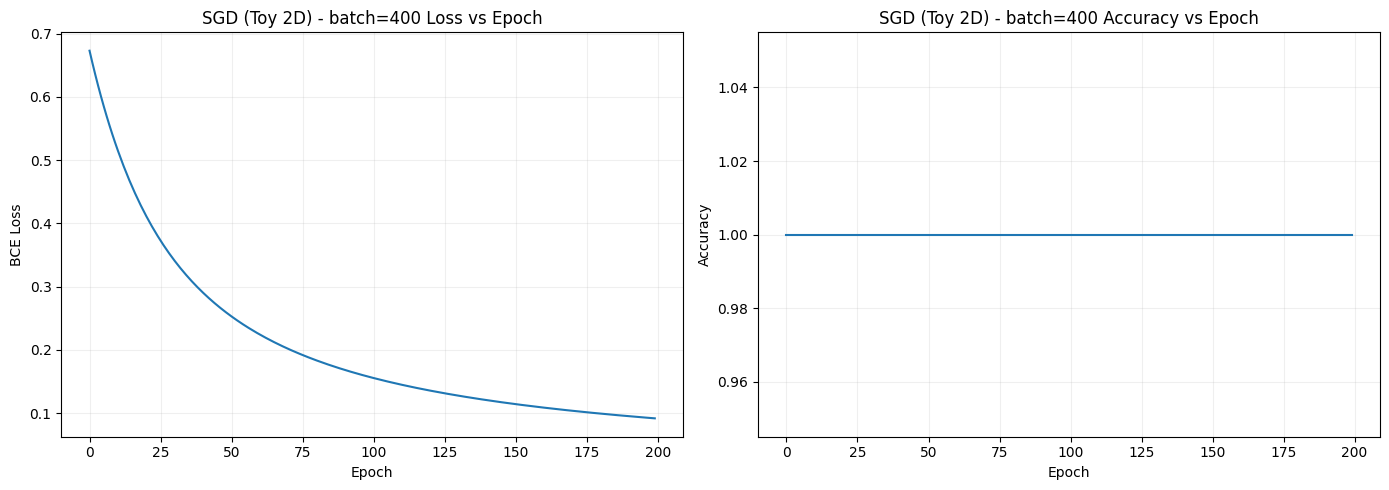

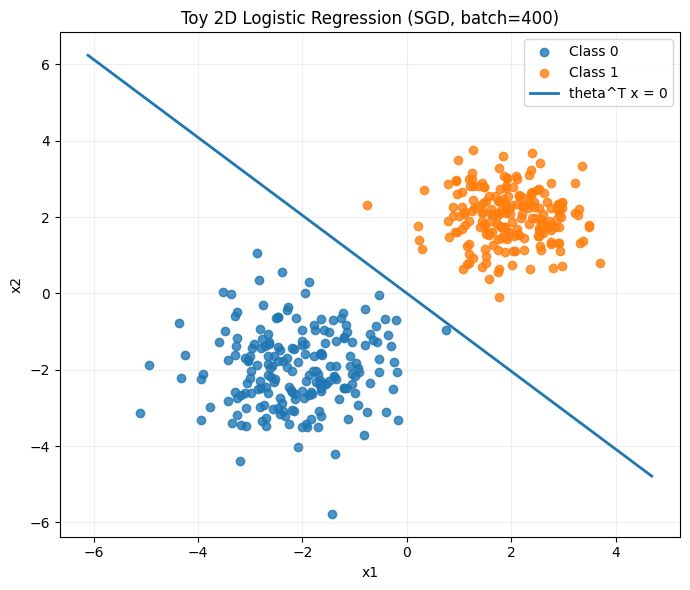


[Exercise 3] Metrics (Toy 2D) using GD model

Threshold = 0.5
Confusion (TP, FP, FN, TN) = (200, 0, 0, 200)
Accuracy  = 1.0000
Precision = 1.0000
Recall    = 1.0000
F1-score  = 1.0000

Threshold = 0.3
Confusion (TP, FP, FN, TN) = (200, 0, 0, 200)
Accuracy  = 1.0000
Precision = 1.0000
Recall    = 1.0000
F1-score  = 1.0000

Threshold = 0.7
Confusion (TP, FP, FN, TN) = (200, 0, 0, 200)
Accuracy  = 1.0000
Precision = 1.0000
Recall    = 1.0000
F1-score  = 1.0000


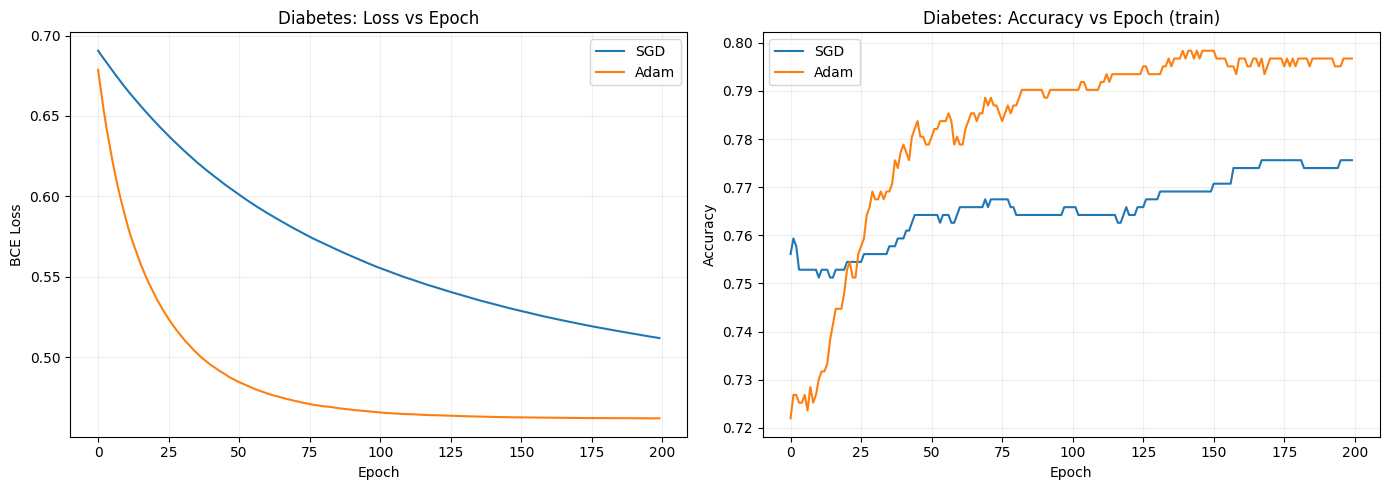


[Exercise 4] Diabetes dataset evaluation (test set)

SGD final test accuracy (thr=0.5) = 0.7320

Diabetes (TEST) metrics for SGD

Threshold = 0.5
Confusion (TP, FP, FN, TN) = (35, 15, 26, 77)
Accuracy  = 0.7320
Precision = 0.7000
Recall    = 0.5738
F1-score  = 0.6306

Threshold = 0.3
Confusion (TP, FP, FN, TN) = (56, 48, 5, 44)
Accuracy  = 0.6536
Precision = 0.5385
Recall    = 0.9180
F1-score  = 0.6788

Threshold = 0.7
Confusion (TP, FP, FN, TN) = (13, 2, 48, 90)
Accuracy  = 0.6732
Precision = 0.8667
Recall    = 0.2131
F1-score  = 0.3421

Adam final test accuracy (thr=0.5) = 0.7386

Diabetes (TEST) metrics for Adam

Threshold = 0.5
Confusion (TP, FP, FN, TN) = (33, 12, 28, 80)
Accuracy  = 0.7386
Precision = 0.7333
Recall    = 0.5410
F1-score  = 0.6226

Threshold = 0.3
Confusion (TP, FP, FN, TN) = (47, 29, 14, 63)
Accuracy  = 0.7190
Precision = 0.6184
Recall    = 0.7705
F1-score  = 0.6861

Threshold = 0.7
Confusion (TP, FP, FN, TN) = (20, 6, 41, 86)
Accuracy  = 0.6928
Precision = 0.769

In [10]:
run_toy_exercises()
csv_file_path = "diabetes.csv"
run_diabetes_ex(csv_file_path)